# Modelo de IA: carregar, executar e avaliar

**Projeto:** Sistema Multiagente de Avaliação de Confiabilidade da Informação (Grupo 1, ResIA)

Este notebook carrega o modelo salvo em `entrega/modelo/modelo_evidencias.pkl`, executa-o e mede o desempenho dele no gold set com as métricas do Manual §7.1.

**O que é o modelo.** O componente de IA avaliado com métricas é o **Agente de Evidências**. Para cada frase de uma notícia, ele procura checagens já publicadas por agências sobre a *mesma alegação* e devolve a **stance** (`apoia`, `contradiz` ou `insuficiente`), o título da checagem e o link. O pipeline tem quatro passos:

1. **Busca densa:** `BAAI/bge-m3` + ChromaDB, com um índice de cerca de 114 mil trechos de checagens.
2. **Termos-chave e ancoragem lexical:** descartam a checagem que troca um nome, número ou doença da frase, ou que não divide nenhuma palavra com ela.
3. **NLI:** com `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, a frase e a alegação checada precisam se implicar em pelo menos uma direção.
4. **Stance:** vem do veredito da agência.

Os dois modelos neurais são pré-treinados. O que foi **ajustado com dados** e está no `.pkl`:

- os limiares de decisão, calibrados no split de calibração;
- o vocabulário de nomes próprios, extraído do corpus;
- o mapeamento veredito → stance;
- a identificação dos pesos (revisões no Hugging Face) e do índice.

O processo e os motivos estão em `entrega/relatorio_tecnico.md`.

**Pré-requisitos:**

- `pip install -r requirements.txt -r entrega/requirements-entrega.txt`;
- o índice `chroma_data/` na raiz do repositório (ou em `EVIDENCE_CHROMA_PATH`);
- os pesos do BGE-M3 e do mDeBERTa, que o Hugging Face baixa na primeira execução (~2,6 GB).

A seção 8 (pipeline completo) também precisa do LM Studio em `localhost:1234` e é pulada se ele estiver fora do ar.

## 1. Ambiente

In [1]:
import json
import os
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

# Raiz do repositório: a pasta acima de entrega/ que tem src/.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "entrega").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # o código de src/ usa caminhos relativos à raiz


# LM Studio (só para a seção 8): LLM_MODEL precisa ser definido antes de importar src.services.llm.
def modelos_lm_studio():
    import requests
    try:
        resposta = requests.get("http://localhost:1234/v1/models", timeout=3)
        return [m["id"] for m in resposta.json()["data"] if "embed" not in m["id"]]
    except Exception:
        return []


LLM_DISPONIVEIS = modelos_lm_studio()
if LLM_DISPONIVEIS and not os.getenv("LLM_MODEL"):
    os.environ["LLM_MODEL"] = LLM_DISPONIVEIS[0]

import pandas as pd
import torch
import transformers
import chromadb
import sentence_transformers

transformers.utils.logging.disable_progress_bar()  # "Loading weights" ao carregar cada modelo
pd.set_option("display.max_colwidth", 120)
print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | transformers {transformers.__version__} | "
      f"sentence-transformers {sentence_transformers.__version__} | chromadb {chromadb.__version__}")
print("Raiz do repositório encontrada (src/ e entrega/); diretório de trabalho ajustado para ela")
print("LM Studio:", ", ".join(LLM_DISPONIVEIS) or "fora do ar (a seção 8 será pulada)")

Python 3.14.6 | torch 2.14.0 | transformers 5.17.0 | sentence-transformers 6.1.0 | chromadb 1.5.9
Raiz do repositório encontrada (src/ e entrega/); diretório de trabalho ajustado para ela
LM Studio: qwen2.5-vl-7b-instruct


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Paleta: superfície clara, tinta neutra para texto, azul único para a série, rampa azul sequencial.
SUPERFICIE, TINTA, TINTA_2, GRADE, AZUL = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul", ["#f0efec", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.edgecolor": GRADE, "axes.grid": False, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
})

## 2. Carregar o modelo salvo

O `.pkl` guarda um objeto `ModeloEvidencias` (`entrega/modelo_evidencias.py`), criado por `entrega/treinar_modelo.py`. Ao executar, o objeto aplica os parâmetros dele no código de `src/` e restaura os anteriores ao terminar.

In [3]:
from entrega.modelo_evidencias import ModeloEvidencias

CAMINHO_MODELO = REPO_ROOT / "entrega" / "modelo" / "modelo_evidencias.pkl"
modelo = ModeloEvidencias.carregar(CAMINHO_MODELO)
print(f"{CAMINHO_MODELO.relative_to(REPO_ROOT)} ({CAMINHO_MODELO.stat().st_size / 1024:.0f} KB)\n")
print(modelo.resumo())

entrega/modelo/modelo_evidencias.pkl (44 KB)

ModeloEvidencias (formato 1) criado em 2026-10-09T17:04:13, commit c6558c5
  embeddings: BAAI/bge-m3 @ 5617a9f61b
  NLI:        MoritzLaurer/mDeBERTa-v3-base-mnli-xnli @ 8adb042d52
  limiares:   similaridade >= 0.55, entailment >= 0.8, ancoragem >= 1 palavra(s)
  busca:      10 trechos por frase, 6 candidatas, até 3 evidências por frase
  vocabulário de nomes: 4150 palavras
  índice:     checagens__baai-bge-m3 com 114337 trechos


In [4]:
pd.DataFrame(
    [(nome, valor) for nome, valor in modelo.hiperparametros.items()]
    + [("vereditos -> contradiz", ", ".join(sorted(modelo.mapa_veredito["contradiz"]))),
       ("vereditos -> apoia", ", ".join(sorted(modelo.mapa_veredito["apoia"]))),
       ("vocabulário de nomes (amostra)", ", ".join(sorted(modelo.vocabulario_nomes)[1000:1012]))],
    columns=["parâmetro", "valor"],
).set_index("parâmetro")

,valor
parâmetro,
SIM_THRESHOLD,0.55
CLAIM_MATCH_MIN_PROB,0.8
MIN_CONTENT_OVERLAP,1
SEARCH_K,10
CLAIM_CANDIDATES,6
MAX_EVIDENCE_PER_SEGMENT,3
vereditos -> contradiz,"e falso, fabricado, fake, falsa, falso, inventado, mentira, mentiroso, montagem"
vereditos -> apoia,"comprovado, correto, e verdade, verdade, verdadeira, verdadeiro"
vocabulário de nomes (amostra),"ct, cts, cuba, cubana, cuiaba, culex, culkin, culta, cultivos, cultura, cumbre, cunha"


O índice e os pesos desta máquina precisam ser os mesmos com que o modelo foi ajustado:

In [5]:
ambiente = modelo.verificar_ambiente()
assert ambiente["indice_ok"], f"Índice não encontrado: {ambiente.get('erro_indice')}. Baixe o chroma_data/ (README)."
{k: v for k, v in ambiente.items() if k != "chroma_path"}

{'colecao': 'checagens__baai-bge-m3',
 'dispositivo': 'mps',
 'trechos_no_indice': 114337,
 'indice_ok': True,
 'embedding_revisao_local': '5617a9f61b028005a4858fdac845db406aefb181',
 'embedding_revisao_igual': True,
 'nli_revisao_local': '8adb042d524ecd5c26d3e3ba0e3fbcf7e2d0864c',
 'nli_revisao_igual': True}

## 3. Como os limiares foram escolhidos (calibração)

Busca em grade do limiar de entailment (`CLAIM_MATCH_MIN_PROB`) **só no split de calibração** (21 frases), com a similaridade mínima fixa em 0,55. A similaridade foi medida no corpus: outro assunto fica em ~0,45, a checagem certa em 0,58–0,68.

Critério de escolha:
1. menos **casamentos errados**, isto é, a checagem de outra alegação citada, que é o erro mais grave (Manual §12.1);
2. depois, mais **cobertura**;
3. no empate, o **centro do platô**.

O split de teste é usado uma única vez, com o limiar escolhido.

In [6]:
calib = pd.DataFrame([{
    "NLI ≥": l["claim_match_min_prob"],
    "cobertura": f"{l['cobertura']['acertos']}/{l['cobertura']['total']}",
    "macro-F1": round(l["macro_f1"]["valor"], 3),
    "stance nas cobertas": f"{l['stance_cobertas']['acertos']}/{l['stance_cobertas']['total']}",
    "evidência inventada": f"{l['evidencia_inventada']['acertos']}/{l['evidencia_inventada']['total']}",
    "casamentos errados": l["casamento_errado"]["evidencias"],
} for l in modelo.calibracao]).set_index("NLI ≥")
print("Critério:", modelo.criterio_selecao)
print("Escolhido: NLI ≥", modelo.hiperparametros["CLAIM_MATCH_MIN_PROB"])
calib

Critério: menos casamentos errados no split de calibração; empate: mais cobertura; empate: o centro do platô de limiares empatados (margem dos dois lados quando o índice muda)
Escolhido: NLI ≥ 0.8


,cobertura,macro-F1,stance nas cobertas,evidência inventada,casamentos errados
NLI ≥,,,,,
0.5,9/11,0.735,9/9,0/7,6
0.6,10/11,0.797,10/10,0/7,5
0.7,10/11,0.797,10/10,0/7,4
0.8,10/11,0.797,10/10,0/7,4
0.9,10/11,0.797,10/10,0/7,4


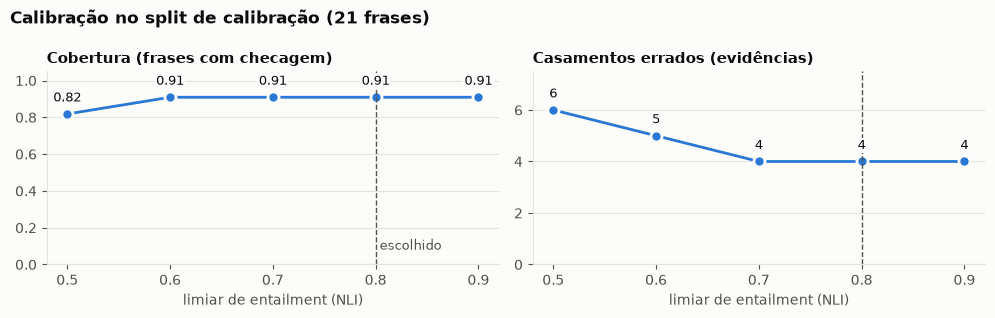

In [7]:
x = [l["claim_match_min_prob"] for l in modelo.calibracao]
series = [("Cobertura (frases com checagem)", [l["cobertura"]["valor"] for l in modelo.calibracao], (0, 1.05), "{:.2f}"),
          ("Casamentos errados (evidências)", [l["casamento_errado"]["evidencias"] for l in modelo.calibracao], None, "{:d}")]
fig, eixos = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (titulo, y, ylim, fmt) in zip(eixos, series):
    ax.plot(x, y, color=AZUL, linewidth=2, marker="o", markersize=8, markeredgecolor=SUPERFICIE, markeredgewidth=2)
    ax.axvline(modelo.hiperparametros["CLAIM_MATCH_MIN_PROB"], color=TINTA_2, linewidth=1, linestyle="--")
    for xi, yi in zip(x, y):
        ax.annotate(fmt.format(yi), (xi, yi), textcoords="offset points", xytext=(0, 9), ha="center", color=TINTA,
                    fontsize=9, bbox=dict(facecolor=SUPERFICIE, edgecolor="none", pad=1))
    ax.set_title(titulo, loc="left")
    ax.set_xlabel("limiar de entailment (NLI)")
    ax.set_xticks(x)
    ax.grid(axis="y", color=GRADE, linewidth=0.8)
    if ylim:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(0, max(y) + 1.5)
eixos[0].text(modelo.hiperparametros["CLAIM_MATCH_MIN_PROB"], 0.08, " escolhido", color=TINTA_2, fontsize=9)
fig.suptitle("Calibração no split de calibração (21 frases)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Executar o modelo

O Ingestor segmenta duas notícias de exemplo, as mesmas da medição de latência (`eval/entradas_latencia.json`), e o modelo procura as checagens de cada frase. A primeira chamada inclui carregar os modelos.

In [8]:
from src.agents.ingestor import segment_text

entradas = json.loads((REPO_ROOT / "eval" / "entradas_latencia.json").read_text(encoding="utf-8"))
linhas = []
for entrada in entradas:
    frases = [s.model_dump() for s in segment_text(entrada["texto"])]
    t0 = time.perf_counter()
    evidencias = modelo.prever(frases)
    segundos = time.perf_counter() - t0
    por_frase = {}
    for ev in evidencias:
        por_frase.setdefault(ev["segment_id"], []).append(ev)
    print(f"{entrada['nome']}: {len(frases)} frases, {len(evidencias)} evidência(s) em {segundos:.1f} s")
    for f in frases:
        for ev in por_frase.get(f["id"], [None]):
            linhas.append({"entrada": entrada["nome"], "frase": f["id"], "texto": f["text"][:70],
                           "stance": ev["stance"] if ev else "—",
                           "agência": f"{ev['source_name']}: {ev['agency_verdict']}" if ev else "",
                           "título da checagem (excerpt)": ev["excerpt"][:90] if ev else ""})
pd.DataFrame(linhas).set_index(["entrada", "frase"])

mamao_dengue: 6 frases, 3 evidência(s) em 5.0 s


carrefour_osasco: 7 frases, 2 evidência(s) em 0.6 s


texto  \
entrada          frase                                                                           
mamao_dengue     s01            URGENTE: os médicos estão escondendo a cura natural da dengue!   
                 s02                O chá da folha de mamão cura a dengue em apenas três dias.   
                 s02                O chá da folha de mamão cura a dengue em apenas três dias.   
                 s02                O chá da folha de mamão cura a dengue em apenas três dias.   
                 s03    Ele estimula a medula óssea a produzir mais plaquetas e evita a dengue   
                 s04    Um especialista em plantas medicinais garante que a folha de mamão sal   
                 s05      Não existe nada melhor do que a natureza para cuidar da nossa saúde.   
                 s06                       Compartilhe com todos antes que apaguem este vídeo!   
carrefour_osasco s01                                                                URGENTE!!!   
                 s02                                                            Justiça feita!   
                 s03    Um grupo de pessoas espancou em Osasco o segurança do Carrefour respon   
                 s03    Um grupo de pessoas espancou em Osasco o segurança do Carrefour respon   
                 s04                Todo mundo sabe que a polícia nunca faz nada nesses casos.   
                 s05    Um advogado muito conhecido garantiu que a população agiu dentro da le   
                 s06    Ou a gente faz justiça com as próprias mãos ou os criminosos vão conti   
                 s07                 Compartilhe antes que a grande mídia apague essa notícia!   

                              stance                              agência  \
entrada          frase                                                      
mamao_dengue     s01               —                                        
                 s02       contradiz              Projeto Comprova: Falso   
                 s02       contradiz                     Aos Fatos: Falso   
                 s02       contradiz                  UOL Notícias: Falso   
                 s03               —                                        
                 s04               —                                        
                 s05               —                                        
                 s06               —                                        
carrefour_osasco s01               —                                        
                 s02               —                                        
                 s03       contradiz           Agência Lupa (2018): Falso   
                 s03    insuficiente  AFP Checamos (2018): Sem evidências   
                 s04               —                                        
                 s05               —                                        
                 s06               —                                        
                 s07               —                                        

                                                                                      título da checagem (excerpt)  
entrada          frase                                                                                              
mamao_dengue     s01                                                                                                
                 s02                                            É falso que chá de folha de mamão combata a dengue  
                 s02          Não há evidências científicas de que chá de folha de mamão combata dengue em humanos  
                 s02                               É falso que folha do mamão é eficaz para o tratamento da dengue  
                 s03                                                                                                
                 s04                                                                                                
 

Frases sem evidência ("—") são o comportamento esperado quando não há checagem da mesma alegação no corpus. Opiniões ("Não existe nada melhor do que a natureza…") e chamadas ("Compartilhe…") não devem receber checagem. O modelo **se abstém** em vez de citar uma checagem parecida.

## 5. Avaliação no gold set

**Conjunto:** `data/gold/evidencias.json`, com 14 entradas e 42 frases. As frases foram escritas como **paráfrases** das alegações checadas, nunca cópias do título, para não inflar a busca. O conjunto é dividido por entrada em **calibração** (7 entradas) e **teste** (7 entradas), divisão feita antes de calibrar.

| Tipo de frase | O que testa | Resposta esperada |
| --- | --- | --- |
| `com_checagem` | recuperação e stance | citar uma das URLs aceitas, com a stance anotada |
| `sem_checagem` | abstenção | nenhuma evidência |
| `fato_parecido`, `troca_numero` | "mesma alegação" | não citar a checagem do fato parecido |
| `desmente` | limitação conhecida | a frase nega o boato; stance esperada `apoia` |

**Métricas** (definições no ADR 3, `docs/agents/evidencias_decisoes.md`):

- **Recall@5** (busca): em frases `com_checagem`, alguma URL aceita aparece entre as 5 primeiras checagens distintas da busca, sem limiar.
- **Cobertura** (agente): em frases `com_checagem`, o agente emitiu uma URL aceita.
- **Macro-F1 de stance**: média do F1 de `apoia`, `contradiz` e `insuficiente`, nas frases `com_checagem` e `desmente`. A stance prevista é a da primeira evidência com URL aceita, ou `insuficiente` se não houver nenhuma (Manual §4.8).
- **Stance nas cobertas**: a mesma comparação, só nas frases em que o agente citou uma URL aceita.
- **Evidência inventada**: fração das frases `sem_checagem` com alguma evidência.
- **Casamento errado**: evidências com uma URL que não é aceita para a frase. É o erro mais grave, com meta 0.

In [9]:
from entrega.modelo_evidencias import carregar_avaliador

avaliador = carregar_avaliador()
gold = avaliador.carregar_json(REPO_ROOT / "data" / "gold" / "evidencias.json")
todas = avaliador.selecionar_frases(gold, "todos")
split_de = {e["id"]: e["split"] for e in gold["entradas"]}
pd.crosstab(pd.Series([t["tipo"] for t in todas], name="tipo"),
            pd.Series([split_de[t["entrada_id"]] for t in todas], name="split"), margins=True, margins_name="total")

split,calibracao,teste,total
tipo,,,
com_checagem,11,12,23
desmente,1,1,2
fato_parecido,1,2,3
sem_checagem,7,5,12
troca_numero,1,1,2
total,21,21,42


In [10]:
resultados, tempos = {}, {}
for split in ("teste", "calibracao", "todos"):
    t0 = time.perf_counter()
    resultados[split], tempos[split] = modelo.avaliar(gold, split)
    print(f"split {split:10s}: {resultados[split]['n_frases']} frases avaliadas em {time.perf_counter() - t0:.1f} s")

split teste     : 21 frases avaliadas em 2.6 s


split calibracao: 21 frases avaliadas em 2.5 s


split todos     : 42 frases avaliadas em 4.5 s


### 5.1 Resultado principal: split de teste

In [11]:
METAS = {"Recall@5": "≥ 0,70", "Cobertura": "—", "Macro-F1 de stance": "≥ 0,65", "Stance nas cobertas": "—",
         "Evidência inventada": "≤ 0,10", "Casamentos errados": "= 0"}


def tabela_metricas(m):
    linhas = {
        "Recall@5": m["recall_at_5"], "Cobertura": m["cobertura"], "Stance nas cobertas": m["stance_cobertas"],
        "Evidência inventada": m["evidencia_inventada"],
    }
    tab = {nome: (f"{v['acertos']}/{v['total']}", v["valor"]) for nome, v in linhas.items()}
    tab["Macro-F1 de stance"] = (f"{m['macro_f1']['n']} frases", m["macro_f1"]["valor"])
    tab["Casamentos errados"] = (f"{m['casamento_errado']['frases']} frases", m["casamento_errado"]["evidencias"])
    return tab


def atende(nome, valor):
    meta = METAS[nome]
    if meta == "—":
        return ""
    alvo = float(meta[2:].replace(",", "."))
    ok = valor >= alvo if meta.startswith("≥") else valor <= alvo if meta.startswith("≤") else valor == alvo
    return "✓ atende" if ok else "✗ não atende"


linhas = []
for nome in METAS:
    linha = {"métrica": nome, "meta (Manual §7.1)": METAS[nome]}
    for split in ("teste", "calibracao", "todos"):
        contagem, valor = tabela_metricas(resultados[split])[nome]
        linha[split] = f"{valor:.2f} ({contagem})" if isinstance(valor, float) else f"{valor} ({contagem})"
    linha["teste vs. meta"] = atende(nome, tabela_metricas(resultados["teste"])[nome][1])
    linhas.append(linha)
pd.DataFrame(linhas).set_index("métrica")

,meta (Manual §7.1),teste,calibracao,todos,teste vs. meta
métrica,,,,,
Recall@5,"≥ 0,70",1.00 (12/12),1.00 (11/11),1.00 (23/23),✓ atende
Cobertura,—,0.83 (10/12),0.91 (10/11),0.87 (20/23),
Macro-F1 de stance,"≥ 0,65",0.74 (13 frases),0.80 (12 frases),0.77 (25 frases),✓ atende
Stance nas cobertas,—,1.00 (10/10),1.00 (10/10),1.00 (20/20),
Evidência inventada,"≤ 0,10",0.00 (0/5),0.00 (0/7),0.00 (0/12),✓ atende
Casamentos errados,= 0,2 (2 frases),4 (3 frases),6 (5 frases),✗ não atende


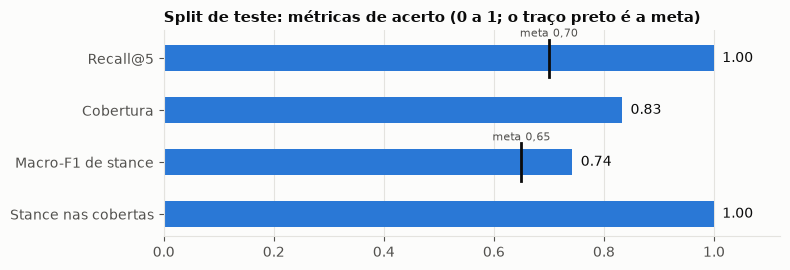

In [12]:
m = resultados["teste"]
nomes = ["Recall@5", "Cobertura", "Macro-F1 de stance", "Stance nas cobertas"]
valores = [m["recall_at_5"]["valor"], m["cobertura"]["valor"], m["macro_f1"]["valor"], m["stance_cobertas"]["valor"]]
metas = [0.70, None, 0.65, None]

fig, ax = plt.subplots(figsize=(8, 2.8))
y = range(len(nomes))[::-1]
ax.barh(list(y), valores, height=0.5, color=AZUL)
for yi, v, meta in zip(y, valores, metas):
    ax.text(v + 0.015, yi, f"{v:.2f}", va="center", color=TINTA, fontsize=10)
    if meta is not None:
        ax.plot([meta, meta], [yi - 0.36, yi + 0.36], color=TINTA, linewidth=2)
        ax.text(meta, yi + 0.42, f"meta {meta:.2f}".replace(".", ","), ha="center", color=TINTA_2, fontsize=8)
ax.set_yticks(list(y), nomes)
ax.set_xlim(0, 1.12)
ax.grid(axis="x", color=GRADE, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("Split de teste: métricas de acerto (0 a 1; o traço preto é a meta)", loc="left")
fig.tight_layout()
plt.show()

### 5.2 Stance por classe e matriz de confusão (teste)

In [13]:
STANCES = ("apoia", "contradiz", "insuficiente")
por_classe = pd.DataFrame(m["macro_f1"]["por_classe"]).T[["precisao", "revocacao", "f1", "suporte", "previstas"]]
por_classe.columns = ["precisão", "revocação", "F1", "suporte", "previstas"]
por_classe.loc["macro (média)"] = [por_classe["precisão"].mean(), por_classe["revocação"].mean(),
                                   m["macro_f1"]["valor"], por_classe["suporte"].sum(), por_classe["previstas"].sum()]
por_classe.round(3)

,precisão,revocação,F1,suporte,previstas
apoia,1.0,0.667,0.800,3.0,2.0
contradiz,1.0,0.750,0.857,8.0,6.0
insuficiente,0.4,1.000,0.571,2.0,5.0
macro (média),0.8,0.806,0.743,13.0,13.0


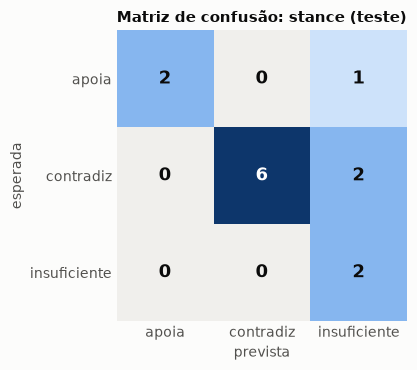

In [14]:
matriz = [[m["matriz_confusao"][e][p] for p in STANCES] for e in STANCES]
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ax.imshow(matriz, cmap=RAMPA_AZUL, vmin=0, vmax=max(max(l) for l in matriz))
for i, linha in enumerate(matriz):
    for j, n in enumerate(linha):
        escuro = n >= 0.55 * max(max(l) for l in matriz)
        ax.text(j, i, n, ha="center", va="center", fontsize=13, fontweight="bold", color="#ffffff" if escuro else TINTA)
ax.set_xticks(range(3), STANCES)
ax.set_yticks(range(3), STANCES)
ax.set_xlabel("prevista")
ax.set_ylabel("esperada")
for lado in ("left", "bottom"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Matriz de confusão: stance (teste)", loc="left")
fig.tight_layout()
plt.show()

A **precisão de `apoia` e de `contradiz` é 1,00**: quando o modelo afirma que uma checagem apoia ou contradiz a frase, ele acerta. Os erros caem todos em `insuficiente`, a classe de abstenção. Isso é deliberado: na dúvida, o modelo não cita. O custo aparece na revocação e no F1 de `insuficiente`.

Conferência independente com o `scikit-learn`, que deve dar o mesmo macro-F1 do cálculo próprio do projeto:

In [15]:
from sklearn.metrics import classification_report, f1_score

pares = [(d["stance_esperada"], d["stance_prevista"]) for d in m["por_frase"] if "stance_prevista" in d]
esperadas, previstas = zip(*pares)
f1_sklearn = f1_score(esperadas, previstas, labels=list(STANCES), average="macro", zero_division=0)
print(classification_report(esperadas, previstas, labels=list(STANCES), zero_division=0, digits=3))
print(f"macro-F1 scikit-learn = {f1_sklearn:.4f} | cálculo do projeto = {m['macro_f1']['valor']:.4f}")
assert abs(f1_sklearn - m["macro_f1"]["valor"]) < 1e-9

              precision    recall  f1-score   support

       apoia      1.000     0.667     0.800         3
   contradiz      1.000     0.750     0.857         8
insuficiente      0.400     1.000     0.571         2

    accuracy                          0.769        13
   macro avg      0.800     0.806     0.743        13
weighted avg      0.908     0.769     0.800        13

macro-F1 scikit-learn = 0.7429 | cálculo do projeto = 0.7429


### 5.3 Análise de erros (teste)

In [16]:
erros = []
for d in m["por_frase"]:
    problemas = []
    if d.get("coberta") is False:
        problemas.append("não citou a checagem esperada")
    if "stance_prevista" in d and d["stance_prevista"] != d["stance_esperada"]:
        problemas.append(f"stance {d['stance_prevista']} (esperada {d['stance_esperada']})")
    if d["urls_nao_aceitas"]:
        problemas.append(f"casamento errado ({len(d['urls_nao_aceitas'])}): " + ", ".join(u.split('/')[2] for u in d["urls_nao_aceitas"]))
    if problemas:
        erros.append({"frase": d["chave"], "tipo": d["tipo"], "texto": d["texto"][:85],
                      "posição da aceita no top 5": d["posicao_aceita"], "problema": "; ".join(problemas)})
pd.DataFrame(erros).set_index("frase")

,tipo,texto,posição da aceita no top 5,problema
frase,,,,
ev01/s03,com_checagem,"No Arkansas, as urnas eletrônicas trocavam sozinhas os votos dados a Donald Trump por",1.0,não citou a checagem esperada; stance insuficiente (esperada contradiz); casamento errado (1): www.estadao.com.br
ev03/s01,desmente,"Ao contrário do que circula nas redes, Lula não virou réu em nenhuma corte internacio",1.0,stance insuficiente (esperada apoia)
ev07/s01,troca_numero,"Silvio Almeida, que deixou o ministério após denúncias de assédio, apareceu em gravaç",NaN,casamento errado (1): projetocomprova.com.br
ev09/s03,com_checagem,"Arrependida, Cármen Lúcia admitiu que agora defende a anistia para os condenados pela",1.0,não citou a checagem esperada; stance insuficiente (esperada contradiz)


Leitura dos erros do teste:

- **Arkansas (ev01/s03):** a checagem certa estava no top 5 da busca, mas o NLI não reconheceu a paráfrase como a mesma alegação. Em troca, o modelo citou uma checagem sobre Kamala Harris, do mesmo tema eleitoral. Esse é o tipo de casamento errado que o NLI deixa passar com confiança alta (0,93–0,98), e nenhum limiar o separa.
- **Cármen Lúcia (ev09/s03):** a busca achou a checagem, mas a etapa "mesma alegação" a recusou. Perde-se cobertura, sem erro grave.
- **Lula réu (ev03/s01), do tipo `desmente`:** a frase *nega* o boato. A checagem casa com a alegação, e não com a negação, então o modelo se abstém. É uma limitação conhecida (ADR 1), que baixa o F1 de propósito.
- **Silvio Almeida (ev07/s01):** checagem do mesmo personagem, mas de outro episódio. Outro casamento errado.

## 6. Componente "mesma alegação": experimento com 37 pares

É o coração do modelo: decidir se uma checagem trata da **mesma alegação** que a frase. O experimento usa 37 pares rotulados (`data/corpus/pares_etapa2.json`): alegações reais do corpus contra paráfrases, trocas de nome ou número, negações e outros fatos. Ele compara variantes da decisão para justificar a combinação adotada (D).

In [17]:
import importlib.util

spec = importlib.util.spec_from_file_location("experimento_etapa2", REPO_ROOT / "data" / "corpus" / "experimento_etapa2.py")
experimento = importlib.util.module_from_spec(spec)
spec.loader.exec_module(experimento)

from src.retrieval import config
from src.retrieval.nli import classify

pares_rotulados = json.loads(experimento.PAIRS_FILE.read_text(encoding="utf-8"))["pares"]
claims, textos = experimento.load_references(config.RAW_DIR)
if not claims:
    print("Aviso: dados brutos do corpus ausentes (data/corpus/raw/); os termos-chave usam só a alegação.")
with modelo.aplicado():
    pares_rotulados = experimento.add_key_terms(experimento.score_pairs(pares_rotulados, classify), claims, textos)

limiar = modelo.hiperparametros["CLAIM_MATCH_MIN_PROB"]
variantes = []
for v, nome in experimento.VARIANTS.items():
    s = experimento.summarize(pares_rotulados, v, limiar)
    vp = sum(1 for p in pares_rotulados if experimento.decide(p, v, limiar) and p["mesma_alegacao"])
    fp = len(s["casou_errado"])
    fn = len(s["paráfrases_perdidas"])
    variantes.append({"variante": f"{v}: {nome}", "acurácia": f"{s['acertos']}/{s['total']}",
                   "precisão (casar)": round(vp / (vp + fp), 3) if vp + fp else None,
                   "revocação (casar)": round(vp / (vp + fn), 3) if vp + fn else None,
                   "casou errado (FP)": fp, "paráfrases perdidas (FN)": fn})
print(f"{len(pares_rotulados)} pares, limiar de entailment {limiar}; adotada: D")
pd.DataFrame(variantes).set_index("variante")

37 pares, limiar de entailment 0.8; adotada: D


,acurácia,precisão (casar),revocação (casar),casou errado (FP),paráfrases perdidas (FN)
variante,,,,,
A: NLI,31/37,0.833,0.833,3,3
B: NLI + normalização,32/37,0.842,0.889,3,2
C: NLI + termos-chave,34/37,1.000,0.833,0,3
D: NLI + normalização + termos-chave,35/37,1.000,0.889,0,2
E: só termos-chave,30/37,0.720,1.000,7,0


O NLI e os termos-chave se completam:

- o NLI sozinho (A, B) aceita trocas de nome ou número entre frases quase iguais, como "dengue" × "chikungunya" com entailment de 0,98;
- os termos-chave sozinhos (E) aceitam negações;
- a normalização ("Foto mostra X" → "X") recupera paráfrases de checagens de mídia.

A variante D é a única com **zero casamentos errados** e o menor número de paráfrases perdidas entre as que usam NLI.

## 7. Estabilidade ao longo do desenvolvimento

Todas as rodadas salvas em `eval/resultados/` (conjunto todo, 42 frases desde 03/10). Entre elas, o índice cresceu de 32 mil para 114 mil trechos. As métricas se mantêm: a busca não piorou com um corpus 3,5 vezes maior.

In [18]:
historico = []
for caminho in sorted((REPO_ROOT / "eval" / "resultados").glob("evidencias_*.json")):
    r = json.loads(caminho.read_text(encoding="utf-8"))
    mt, cfg = r["metricas"], r["configuracao"]
    historico.append({
        "arquivo": caminho.stem, "data": r["data"][:10], "split": r["split"], "frases": mt["n_frases"],
        "trechos no índice": cfg.get("trechos_no_indice"), "embedding": cfg["embedding_model"].split("/")[-1],
        "NLI ≥": cfg["claim_match_min_prob"],
        "Recall@5": round(mt["recall_at_5"]["valor"], 2), "cobertura": round(mt["cobertura"]["valor"], 2),
        "macro-F1": round(mt["macro_f1"]["valor"], 2), "inventada": round(mt["evidencia_inventada"]["valor"], 2),
        "casamentos errados": mt["casamento_errado"]["evidencias"],
    })
mt = resultados["todos"]
historico.append({"arquivo": "este notebook", "data": time.strftime("%Y-%m-%d"), "split": "todos", "frases": mt["n_frases"],
                  "trechos no índice": ambiente["trechos_no_indice"], "embedding": modelo.embedding_model.split("/")[-1],
                  "NLI ≥": limiar, "Recall@5": round(mt["recall_at_5"]["valor"], 2),
                  "cobertura": round(mt["cobertura"]["valor"], 2), "macro-F1": round(mt["macro_f1"]["valor"], 2),
                  "inventada": round(mt["evidencia_inventada"]["valor"], 2),
                  "casamentos errados": mt["casamento_errado"]["evidencias"]})
pd.DataFrame(historico).set_index("arquivo")

,data,split,frases,trechos no índice,embedding,NLI ≥,Recall@5,cobertura,macro-F1,inventada,casamentos errados
arquivo,,,,,,,,,,,
evidencias_2026-10-01,2026-10-01,todos,36,32094,bge-m3,0.5,0.95,0.74,0.61,0.0,7
evidencias_2026-10-01_2,2026-10-01,todos,36,32094,bge-m3,0.5,0.95,0.79,0.72,0.0,7
evidencias_2026-10-01_3,2026-10-01,teste,18,32094,bge-m3,0.8,1.00,0.80,0.69,0.0,2
evidencias_2026-10-03_2,2026-10-03,todos,36,36099,bge-m3,0.8,0.95,0.79,0.72,0.0,4
evidencias_2026-10-03_3,2026-10-03,todos,36,36099,multilingual-e5-large,0.8,0.84,0.68,0.69,0.0,1
evidencias_2026-10-03_4,2026-10-03,todos,42,36071,bge-m3,0.8,0.96,0.83,0.77,0.0,4
evidencias_2026-10-03_5,2026-10-03,todos,42,36071,multilingual-e5-large,0.8,0.74,0.61,0.56,0.0,1
evidencias_2026-10-07,2026-10-07,todos,42,99464,bge-m3,0.8,0.96,0.83,0.77,0.0,5
evidencias_2026-10-08,2026-10-08,todos,42,108607,bge-m3,0.8,0.96,0.83,0.74,0.0,7


Duas linhas merecem destaque:

- **`evidencias_2026-10-03_5`** usa o `multilingual-e5-large` no lugar do BGE-M3, no mesmo índice e no mesmo conjunto. O resultado (Recall@5 0,74 × 0,96 e macro-F1 0,56 × 0,77) foi o critério para escolher o BGE-M3.
- **01/10:** a primeira rodada (macro-F1 0,61, 7 casamentos errados) motivou a correção dos termos-chave (vocabulário de nomes do corpus) e a calibração do NLI.

## 8. Pipeline completo (opcional: precisa do LM Studio)

O modelo de evidências roda dentro do sistema multiagente (LangGraph): Ingestor → (Evidências | Texto | Socrático) → Sintetizador. Os agentes de Texto, Socrático e Sintetizador usam um LLM local (Qwen 2.5 7B no LM Studio) com *prompting* e validação determinística; não há treino. Esta seção roda o grafo inteiro e mede:

- a **latência** (meta: p50 < 3 min);
- a **validade de citação**: toda URL do dossiê precisa estar nas evidências (meta 1,00);
- o **vazamento de veredito** no texto escrito pelo LLM (meta 0).

In [19]:
pipeline = []
if not LLM_DISPONIVEIS:
    print("LM Studio fora do ar: seção pulada.")
else:
    from src.graph import construir_grafo
    from src.guardrails.citacoes import extrair_urls, urls_invalidas
    from src.guardrails.veredito import termos_de_veredito
    from src.medicao import executar
    from src.state import initial_state

    def secao(dossie, titulo):
        partes = dossie.split(f"## {titulo}", 1)
        return partes[1].split("\n## ", 1)[0] if len(partes) == 2 else ""

    print("LLM:", os.environ["LLM_MODEL"])
    grafo = construir_grafo()
    with modelo.aplicado():
        for entrada in entradas:
            execucao = executar(grafo, initial_state(entrada["texto"]))
            estado = execucao.estado
            evidencias = estado.evidence or []
            urls = extrair_urls(estado.dossier)
            tipo_da_frase = {s.segment_id: s.kind for s in (estado.text_report.statements if estado.text_report else [])}
            pipeline.append({
                "entrada": entrada["nome"], "frases": len(estado.segments), "evidências": len(evidencias),
                "frases factuais (Agente de Texto)": sum(k == "factual" for k in tipo_da_frase.values()),
                "evidências em frases marcadas como opinião": sum(tipo_da_frase.get(e.segment_id) == "valor" for e in evidencias),
                "total (s)": round(execucao.total, 1),
                **{f"{no} (s)": round(s, 1) for no, s in execucao.duracao_por_no.items()},
                "URLs no dossiê": len(urls), "URLs inválidas": len(urls_invalidas(estado.dossier, evidencias)),
                "termos de veredito (texto do LLM)": termos_de_veredito(secao(estado.dossier, "Como o texto argumenta")),
                "avisos": estado.warnings,
            })
            if entrada is entradas[0]:
                dossie_exemplo = estado.dossier
pd.DataFrame(pipeline).set_index("entrada").T if pipeline else None

LLM: qwen2.5-vl-7b-instruct


Agente Socrático: pergunta descartada, menciona 'oms' (fora da notícia): Existem outros métodos de tratamento aprovados pela OMS para a dengue que o chá de mamão poderia substituir?


entrada,mamao_dengue,carrefour_osasco
frases,6,7
evidências,3,2
frases factuais (Agente de Texto),0,1
evidências em frases marcadas como opinião,3,0
total (s),25.8,40.3
ingestor (s),0.0,0.1
agente_evidencias (s),0.7,2.0
agente_texto (s),17.9,25.1
agente_socratico (s),8.2,9.0
sintetizador (s),7.8,15.1


In [20]:
from IPython.display import Markdown, display

if pipeline:
    display(Markdown("**Dossiê gerado para a primeira entrada:**\n\n---\n\n" + dossie_exemplo))

**Dossiê gerado para a primeira entrada:**

---

## Resumo
- 6 frases analisadas: nenhuma afirmação factual e 6 opiniões.
- Nenhuma afirmação factual para checar.
- 4 padrões de argumentação apontados.
- O dossiê não dá veredito: mostra o que já foi checado, como o texto argumenta e o que perguntar antes de decidir.

## O que as checagens dizem
- Nenhuma checagem encontrada no nosso banco para as frases factuais. Isso não confirma nem descarta essas frases.

## Como o texto argumenta
- Urgência: "URGENTE" abre o texto em caixa alta e pede atenção imediata, sem indicar um prazo real.
- Adjetivação extrema: "em apenas três dias" promete um resultado rápido e completo.
- Autoridade sem identificação: "Um especialista em plantas medicinais garante" cita uma autoridade sem nome nem fonte verificável.
- Urgência: "antes que apaguem este vídeo!" pede ação imediata sem motivo concreto.

## Perguntas para pensar antes de decidir
1. Onde e quando foram publicadas as pesquisas sobre o chá de mamão como tratamento para a dengue?
2. Qual é a formação do especialista em plantas medicinais citado no texto, e qual foi seu último estudo reconhecido?

## Limites desta análise
- O texto não tem data de publicação.
- O texto não tem link de origem.
- O banco de checagens pode não conter checagens mais recentes que a última coleta.

**Como ler a integração.** O dossiê só mostra a stance de frases que o Agente de Texto classificou como **factuais**: opinião não tem checagem (Manual §4.8). A linha "evidências em frases marcadas como opinião" da tabela acima conta as checagens que o modelo de evidências encontrou e que o dossiê deixou de exibir por causa dessa classificação.

Quando o LLM marca como opinião uma alegação checável (por exemplo, "O chá da folha de mamão cura a dengue em três dias"), a checagem correta some do dossiê, embora o modelo de evidências tenha acertado. A qualidade do fato/valor do Agente de Texto limita, portanto, o que o modelo entrega ao usuário. O relatório técnico (seções 5.5 e 8) discute esse ponto.

## 9. Resumo dos resultados

In [21]:
mt = resultados["teste"]
resumo = [
    ("Evidências: Recall@5", "≥ 0,70", f"{mt['recall_at_5']['valor']:.2f}"),
    ("Evidências: macro-F1 de stance", "≥ 0,65", f"{mt['macro_f1']['valor']:.2f}"),
    ("Evidências: evidência inventada", "≤ 0,10", f"{mt['evidencia_inventada']['valor']:.2f}"),
    ("Evidências: casamentos errados", "= 0", f"{mt['casamento_errado']['evidencias']}"),
    ("Evidências: cobertura", "—", f"{mt['cobertura']['valor']:.2f}"),
    ("Mesma alegação (37 pares, variante D)", "0 casou errado",
     next(f"{l['acurácia']}, {l['casou errado (FP)']} casou errado" for l in variantes if l["variante"].startswith("D"))),
]
if pipeline:
    from statistics import median

    totais = [p["total (s)"] for p in pipeline]
    invalidas = sum(p["URLs inválidas"] for p in pipeline)
    urls_total = sum(p["URLs no dossiê"] for p in pipeline)
    resumo += [
        ("Sistema: latência ponta a ponta", "p50 < 180 s",
         f"mediana {median(totais):.1f} s (máx. {max(totais):.1f} s, {len(totais)} entradas)"),
        ("Sintetizador: validade de citação", "1,00", f"{(urls_total - invalidas) / urls_total:.2f}" if urls_total else "sem URLs"),
        ("Sintetizador: vazamento de veredito", "0", f"{sum(bool(p['termos de veredito (texto do LLM)']) for p in pipeline)} de {len(pipeline)} dossiês"),
    ]
tabela_resumo = pd.DataFrame(resumo, columns=["métrica (split de teste quando aplicável)", "meta", "obtido"]).set_index(
    "métrica (split de teste quando aplicável)")
tabela_resumo

,meta,obtido
métrica (split de teste quando aplicável),,
Evidências: Recall@5,"≥ 0,70",1.00
Evidências: macro-F1 de stance,"≥ 0,65",0.74
Evidências: evidência inventada,"≤ 0,10",0.00
Evidências: casamentos errados,= 0,2
Evidências: cobertura,—,0.83
"Mesma alegação (37 pares, variante D)",0 casou errado,"35/37, 0 casou errado"
Sistema: latência ponta a ponta,p50 < 180 s,"mediana 33.0 s (máx. 40.3 s, 2 entradas)"
Sintetizador: validade de citação,"1,00",1.00
Sintetizador: vazamento de veredito,0,0 de 2 dossiês


In [22]:
# Guarda os números deste notebook (o relatório técnico cita este arquivo).
saida = REPO_ROOT / "entrega" / "resultados" / "avaliacao_notebook.json"
saida.write_text(json.dumps({
    "data": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "modelo": {"arquivo": str(CAMINHO_MODELO.relative_to(REPO_ROOT)), "hiperparametros": modelo.hiperparametros,
               "embedding": [modelo.embedding_model, modelo.embedding_revision], "nli": [modelo.nli_model, modelo.nli_revision]},
    "ambiente": {k: v for k, v in ambiente.items() if k != "chroma_path"},
    "metricas": {s: {k: v for k, v in r.items() if k != "por_frase"} for s, r in resultados.items()},
    "experimento_mesma_alegacao": variantes,
    "pipeline": pipeline,
    "resumo": [dict(zip(["metrica", "meta", "obtido"], r)) for r in resumo],
}, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Resultados salvos em", saida.relative_to(REPO_ROOT))

Resultados salvos em entrega/resultados/avaliacao_notebook.json
